# Health Facility Stockout Analysis

## Project Overview

This project analyzes health facility stockout data to identify patterns in medicine and health-supply availability.

The analysis examines stockout patterns across products, facility types, districts, inventory conditions, and time. The goal is to generate data-driven insights that can support better inventory management and help reduce situations where essential health products are unavailable.

## Research Question

What patterns can be identified in health facility stockouts, and which factors are associated with higher stockout frequency?

## Objectives

- Identify products with higher stockout rates.
- Examine stockout patterns across different facility types.
- Compare stockout rates across districts.
- Analyze how stockout rates vary over time.
- Examine the relationship between stockouts and inventory conditions.
- Generate insights that could support better inventory management decisions.

## Dataset

This project uses health facility-level consumption and stock data from Sierra Leone, obtained from the Dryad research dataset accompanying the study *Improving Access to Essential Medicines via Decision-Aware Machine Learning*.

The dataset contains records covering products, inventory movements, consumption, stockout status, facility characteristics, and district information.

The S2 dataset used in this analysis contains **457,225 records and 16 variables**.

### Data Source

Chung, Angel Tsai-Hsuan; Abdulai, Jatu; Bayoh, Patrick; et al. (2026). *Data from: Improving access to essential medicines via decision-aware machine learning*. Dryad.

DOI: 10.5061/dryad.h9w0vt4tw

## Tools Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Analysis Approach

The analysis follows an exploratory data analysis approach:

1. Data loading and inspection
2. Stockout rate calculation
3. Product-level analysis
4. Facility-level analysis
5. District-level analysis
6. Facility-type analysis
7. Inventory condition analysis
8. Monthly trend analysis
9. Findings and interpretation
10. Conclusion and limitations

## Data Loading and Inspection

The dataset is loaded into a Pandas DataFrame for analysis. Initial inspection is performed to understand the structure, size, variables, and data types.

In [6]:
import pandas as pd

df = pd.read_csv("S2.csv/S2_Dhis2Data.csv")

df.shape

(457225, 16)

In [7]:
df.head()

,hf_pk,name1,date,stockout,received,consumption,closeBalance,openBalance,facility_type,lat,long,district,quarter,productID,normAvg,normStd
0,663,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",10/1/19,0,0,59,0,59,MCHP,9.089409,-12.00467,Bombali,2019Q4,1,152.030426,228.309369
1,667,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",10/1/19,0,0,70,0,70,CHP,8.903324,-12.04545,Bombali,2019Q4,1,152.030426,228.309369
2,745,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",10/1/19,1,0,14,0,14,CHP,8.807020,-12.08181,Bombali,2019Q4,1,152.030426,228.309369
3,753,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",10/1/19,0,0,100,0,100,CHP,8.791610,-12.06068,Bombali,2019Q4,1,152.030426,228.309369
4,725,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",10/1/19,0,0,100,0,100,MCHP,9.032880,-12.04858,Bombali,2019Q4,1,152.030426,228.309369


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 457225 entries, 0 to 457224
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   hf_pk          457225 non-null  int64  
 1   name1          457225 non-null  str    
 2   date           457225 non-null  str    
 3   stockout       457225 non-null  int64  
 4   received       457225 non-null  int64  
 5   consumption    457225 non-null  int64  
 6   closeBalance   457225 non-null  int64  
 7   openBalance    457225 non-null  int64  
 8   facility_type  457225 non-null  str    
 9   lat            457225 non-null  float64
 10  long           457225 non-null  float64
 11  district       457225 non-null  str    
 12  quarter        457225 non-null  str    
 13  productID      457225 non-null  int64  
 14  normAvg        457225 non-null  float64
 15  normStd        457225 non-null  float64
dtypes: float64(4), int64(7), str(5)
memory usage: 55.8 MB


## Exploratory Data Analysis

This section explores the dataset to identify patterns in health facility stockouts across products, facilities, locations, facility types, inventory conditions, and time.

In [9]:
df["stockout"].value_counts()

stockout
0    395269
1     61956
Name: count, dtype: int64

### Overall Stockout Rate

In [10]:
stockout_rate = df["stockout"].mean() * 100
print(f"Overall stockout rate: {stockout_rate:.2f}%")

Overall stockout rate: 13.55%


### Product-Level Analysis

In [11]:
product_stockouts = (
    df.groupby("name1")
      .agg(
          total_records=("stockout", "count"),
          stockout_records=("stockout", "sum")
      )
)

product_stockouts["stockout_rate"] = (
    product_stockouts["stockout_records"]
    / product_stockouts["total_records"]
    * 100
)

product_stockouts = (
    product_stockouts[product_stockouts["total_records"] >= 100]
    .sort_values("stockout_rate", ascending=False)
)

product_stockouts.head(10)

,total_records,stockout_records,stockout_rate
name1,,,
"Ciprofloxacin 500mg, Tab",2261,670,29.632906
"Paracetamol (Acetaminophen) 500mg, Tab",23352,6089,26.074854
"Ampicillin 500mg, Pdr for IM/IV, Inj, Vial",20859,5392,25.849753
"Paracetamol (Acetaminophen) 250mg, Dispersible, Tab",27810,6736,24.221503
"Glove, Exam, Latex, Medium, Nonsterile, Disposable, Pcs",18615,4433,23.814128
"Ferrous Sulphate 200mg, Tab",2298,522,22.715405
"Neomycin & Bacitracin 0.5% & 500IU/g, Ointment, 15g, Tube",681,150,22.026432
"Aluminium Hydroxide 500mg, Tab",391,82,20.971867
"Ceftriaxone 250mg, Pdr for Inj",562,112,19.928826


### Facility-Level Analysis

In [12]:
facility_stockouts = (
    df.groupby("hf_pk")
      .agg(
          total_records=("stockout", "count"),
          stockout_records=("stockout", "sum")
      )
)

facility_stockouts["stockout_rate"] = (
    facility_stockouts["stockout_records"]
    / facility_stockouts["total_records"]
    * 100
)

facility_stockouts = (
    facility_stockouts[facility_stockouts["total_records"] >= 100]
    .sort_values("stockout_rate", ascending=False)
)

facility_stockouts.head(10)

,total_records,stockout_records,stockout_rate
hf_pk,,,
250,203,104,51.231527
197,381,160,41.994751
10105,249,87,34.939759
424,348,118,33.908046
262,443,146,32.957111
34,211,67,31.753555
985,462,144,31.168831
249,196,61,31.122449
643,581,179,30.808950


In [13]:
district_stockouts = (
    df.groupby("district")
      .agg(
          total_records=("stockout", "count"),
          stockout_records=("stockout", "sum")
      )
)

district_stockouts["stockout_rate"] = (
    district_stockouts["stockout_records"]
    / district_stockouts["total_records"]
    * 100
)

district_stockouts = (
    district_stockouts[district_stockouts["total_records"] >= 500]
    .sort_values("stockout_rate", ascending=False)
)

district_stockouts.head(10)

,total_records,stockout_records,stockout_rate
district,,,
Kono,21386,4168,19.489386
Western Rural,12592,2301,18.273507
Western Urban,10314,1731,16.783013
Bombali,30239,4764,15.754489
Bonthe,19427,3035,15.622587
Kailahun,30977,4658,15.036963
Moyamba,22653,3220,14.214453
Bo,51899,7166,13.807588
Kenema,52024,7136,13.716746


In [14]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"], format="mixed")

# Calculate monthly stockout rate
monthly_stockouts = (
    df.groupby("date")
      .agg(
          total_records=("stockout", "count"),
          stockout_records=("stockout", "sum")
      )
)

monthly_stockouts["stockout_rate"] = (
    monthly_stockouts["stockout_records"]
    / monthly_stockouts["total_records"]
    * 100
)

monthly_stockouts

,total_records,stockout_records,stockout_rate
date,,,
2019-10-01,7229,336,4.647946
2019-11-01,7487,491,6.558034
2019-12-01,8441,152,1.800735
2020-01-01,8067,342,4.239494
2020-02-01,7307,455,6.226906
2020-03-01,7644,239,3.126635
2020-04-01,8623,236,2.736867
2020-05-01,8344,1453,17.413710
2020-06-01,8816,1502,17.037205


In [15]:
# Highest stockout months
highest_months = monthly_stockouts.sort_values(
    "stockout_rate", ascending=False
).head(10)

highest_months

,total_records,stockout_records,stockout_rate
date,,,
2022-07-01,6399,1441,22.519144
2023-06-01,8343,1798,21.551001
2022-12-01,8006,1681,20.996752
2023-09-01,13628,2826,20.736719
2022-06-01,7456,1531,20.533798
2021-09-01,8365,1704,20.370592
2023-03-01,8347,1694,20.294717
2021-10-01,7001,1264,18.054564
2021-05-01,10450,1886,18.047847


In [16]:
# Highest stockout months
highest_months = monthly_stockouts.sort_values(
    "stockout_rate", ascending=False
).head(10)

highest_months

,total_records,stockout_records,stockout_rate
date,,,
2022-07-01,6399,1441,22.519144
2023-06-01,8343,1798,21.551001
2022-12-01,8006,1681,20.996752
2023-09-01,13628,2826,20.736719
2022-06-01,7456,1531,20.533798
2021-09-01,8365,1704,20.370592
2023-03-01,8347,1694,20.294717
2021-10-01,7001,1264,18.054564
2021-05-01,10450,1886,18.047847


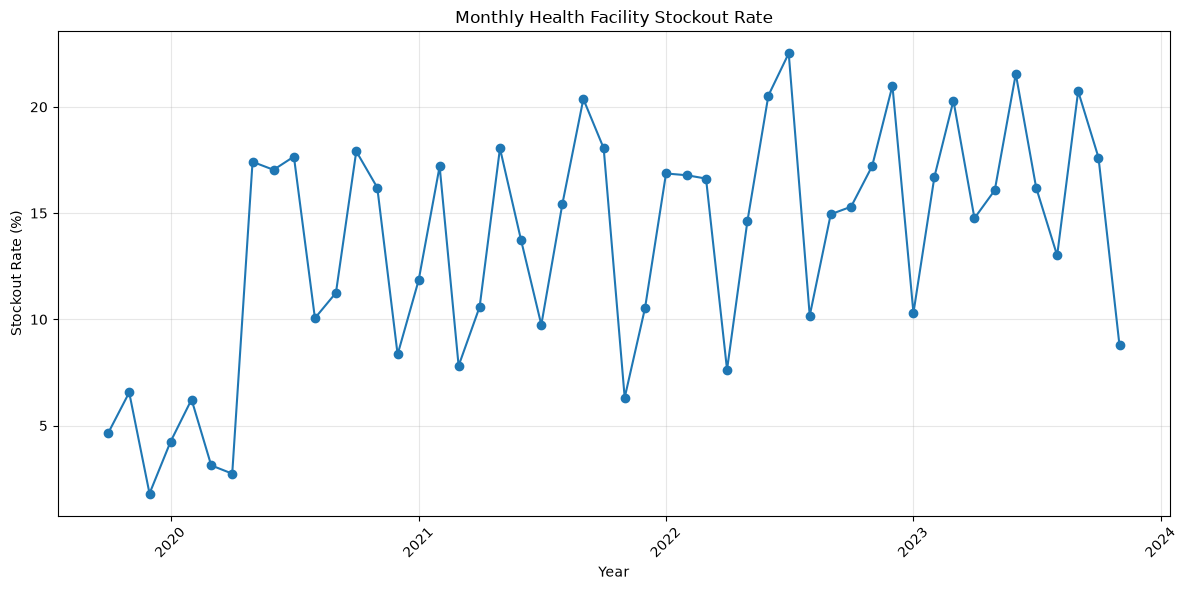

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_stockouts.index,
    monthly_stockouts["stockout_rate"],
    marker="o"
)

plt.title("Monthly Health Facility Stockout Rate")
plt.xlabel("Year")
plt.ylabel("Stockout Rate (%)")

# Show every year clearly on the x-axis
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
facility_type_stockouts = (
    df.groupby("facility_type")
      .agg(
          total_records=("stockout", "count"),
          stockout_records=("stockout", "sum")
      )
)

facility_type_stockouts["stockout_rate"] = (
    facility_type_stockouts["stockout_records"]
    / facility_type_stockouts["total_records"]
    * 100
)

facility_type_stockouts.sort_values(
    "stockout_rate",
    ascending=False
)

,total_records,stockout_records,stockout_rate
facility_type,,,
CHP,138520,19765,14.268698
MCHP,215432,28857,13.394946
CHC,101256,13273,13.108359
Hospital,2017,61,3.024294


In [19]:
stockout_inventory = (
    df.groupby("stockout")
      .agg(
          records=("stockout", "count"),
          avg_open_balance=("openBalance", "mean"),
          avg_close_balance=("closeBalance", "mean"),
          avg_received=("received", "mean"),
          avg_consumption=("consumption", "mean")
      )
)

stockout_inventory

,records,avg_open_balance,avg_close_balance,avg_received,avg_consumption
stockout,,,,,
0,395269,538.057371,568.687719,180.808768,152.483461
1,61956,178.490300,8.012025,42.165682,215.585141


In [20]:
top_products = product_stockouts.head(10).sort_values("stockout_rate")

top_products

,total_records,stockout_records,stockout_rate
name1,,,
"Water for Injection 10ml, Inj, Amp",12520,2192,17.507987
"Ceftriaxone 250mg, Pdr for Inj",562,112,19.928826
"Aluminium Hydroxide 500mg, Tab",391,82,20.971867
"Neomycin & Bacitracin 0.5% & 500IU/g, Ointment, 15g, Tube",681,150,22.026432
"Ferrous Sulphate 200mg, Tab",2298,522,22.715405
"Glove, Exam, Latex, Medium, Nonsterile, Disposable, Pcs",18615,4433,23.814128
"Paracetamol (Acetaminophen) 250mg, Dispersible, Tab",27810,6736,24.221503
"Ampicillin 500mg, Pdr for IM/IV, Inj, Vial",20859,5392,25.849753
"Paracetamol (Acetaminophen) 500mg, Tab",23352,6089,26.074854


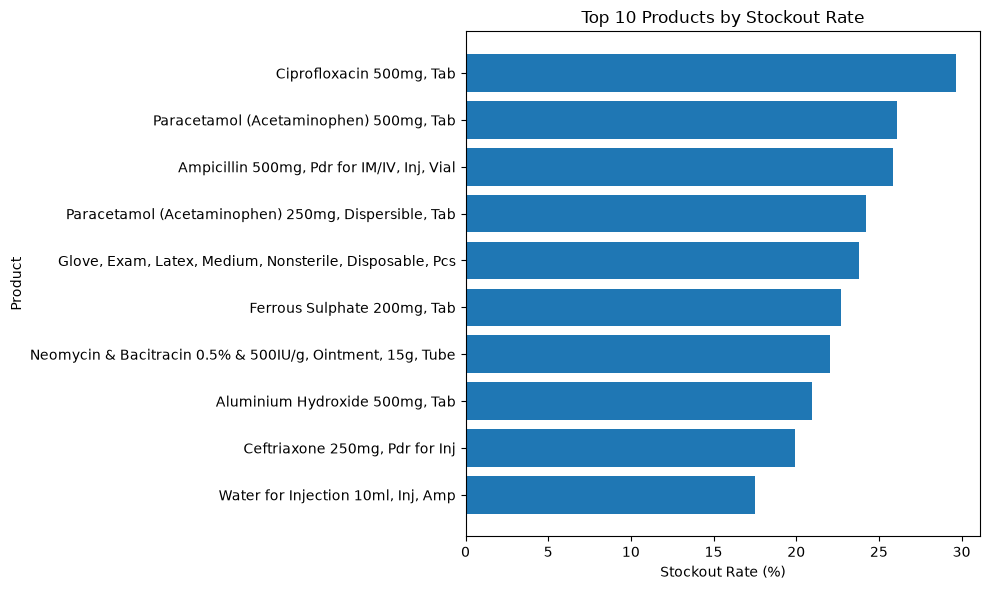

In [21]:
import matplotlib.pyplot as plt

top_products = product_stockouts.head(10).sort_values("stockout_rate")

plt.figure(figsize=(10, 6))
plt.barh(top_products.index, top_products["stockout_rate"])

plt.title("Top 10 Products by Stockout Rate")
plt.xlabel("Stockout Rate (%)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

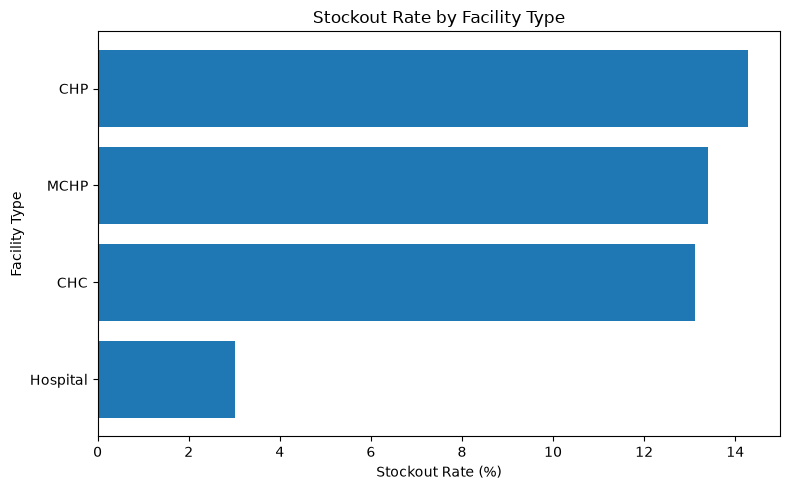

In [22]:
facility_type_chart = facility_type_stockouts.sort_values("stockout_rate")

plt.figure(figsize=(8, 5))
plt.barh(
    facility_type_chart.index,
    facility_type_chart["stockout_rate"]
)

plt.title("Stockout Rate by Facility Type")
plt.xlabel("Stockout Rate (%)")
plt.ylabel("Facility Type")

plt.tight_layout()
plt.show()

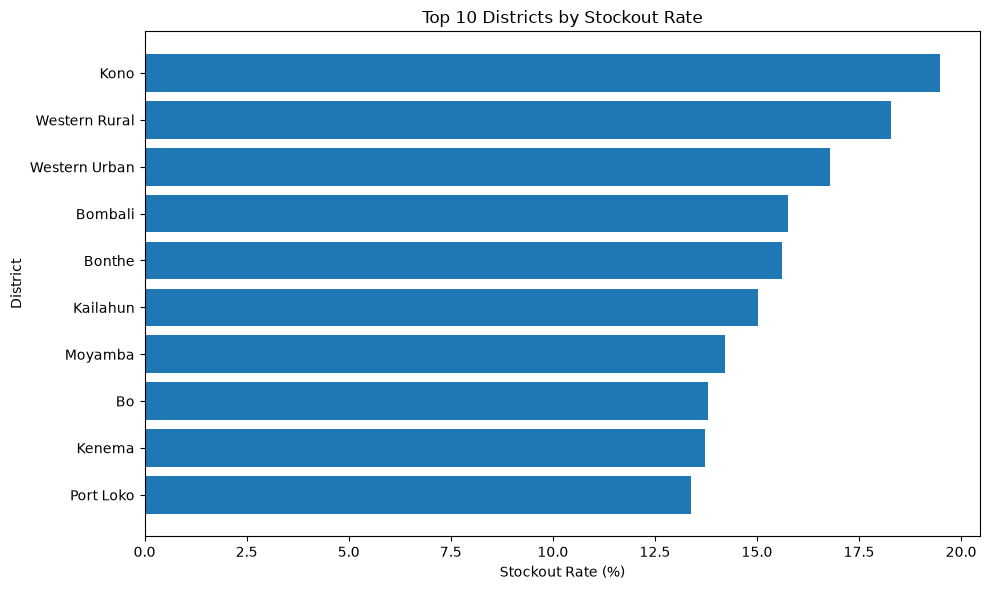

In [23]:
top_districts = district_stockouts.head(10).sort_values("stockout_rate")

plt.figure(figsize=(10, 6))
plt.barh(
    top_districts.index,
    top_districts["stockout_rate"]
)

plt.title("Top 10 Districts by Stockout Rate")
plt.xlabel("Stockout Rate (%)")
plt.ylabel("District")

plt.tight_layout()
plt.show()

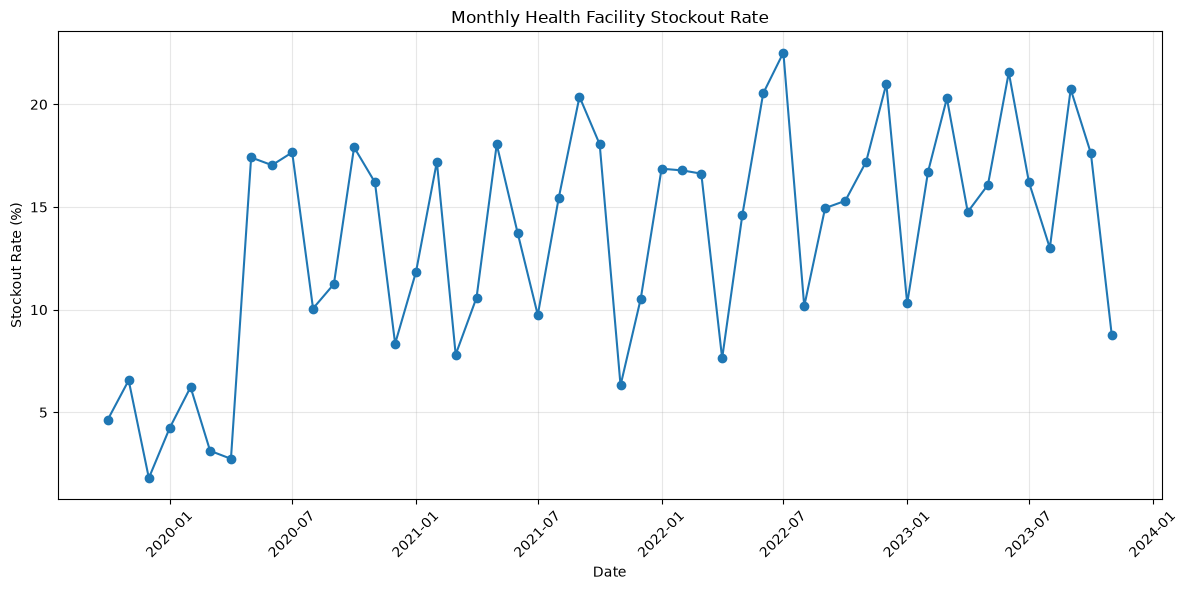

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_stockouts.index,
    monthly_stockouts["stockout_rate"],
    marker="o"
)

plt.title("Monthly Health Facility Stockout Rate")
plt.xlabel("Date")
plt.ylabel("Stockout Rate (%)")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Findings

### 1. Overall Stockout Rate

The dataset contains 457,225 health facility-product records. Of these, 61,956 were recorded as stockouts, giving an overall stockout rate of approximately 13.55%.

This indicates that stockouts occurred in a substantial proportion of the records analyzed.

### 2. Products with Higher Stockout Rates

Stockout rates varied considerably across products. Among products with at least 100 records, Ciprofloxacin 500mg had the highest observed stockout rate at approximately 29.63%.

Other products with relatively high stockout rates included Paracetamol 500mg, Ampicillin 500mg, Paracetamol 250mg, and examination gloves.

This suggests that medicine and supply availability was not uniform across products.

### 3. Stockouts and Inventory Conditions

Records associated with stockouts showed substantially lower average inventory balances than records without stockouts.

The average closing balance was approximately 568.69 for records without a stockout, compared with only 8.01 for records with a stockout.

Stockout records also had higher average consumption (215.59) and lower average quantities received (42.17).

These patterns suggest an association between stockouts and unfavorable inventory conditions.

### 4. Differences Across Facility Types

Stockout rates varied by facility type.

CHP facilities had the highest observed stockout rate at approximately 14.27%, followed by MCHP at 13.39% and CHC at 13.11%. Hospitals had the lowest observed rate at approximately 3.02%.

These differences show that stockout patterns may vary according to facility type.

### 5. Geographic Differences

Stockout rates also varied across districts.

Kono had the highest observed stockout rate among the districts included in the analysis, at approximately 19.49%, followed by Western Rural at 18.27% and Western Urban at 16.78%.

This indicates that stockout patterns differed across locations.

### 6. Variation Over Time

Monthly stockout rates fluctuated substantially throughout the period covered by the dataset.

Some of the highest observed monthly rates occurred in July 2022 (22.52%), June 2023 (21.55%), December 2022 (21.00%), and September 2023 (20.74%).

This suggests that stockout levels were not constant over time and that certain periods experienced considerably higher stockout rates.

## Conclusion

This analysis examined health facility stockout patterns across products, facility types, districts, inventory conditions, and time.

The results show that stockouts were not evenly distributed across the dataset. Certain products and districts recorded higher stockout rates, while stockout levels also varied across facility types and months.

The analysis also showed a strong difference in inventory conditions between stockout and non-stockout records. Stockout records had much lower average closing balances and received fewer quantities, while average consumption was higher.

Overall, these findings suggest that monitoring inventory levels, consumption patterns, and stockout trends could provide useful information for improving medicine availability and supporting better inventory management decisions.

## Limitations

- This analysis is descriptive and identifies patterns and associations; it does not establish causal relationships.
- The dataset represents health facilities and products included in the source dataset and may not represent all health facilities.
- Some products have considerably fewer records than others, so comparisons involving small numbers of observations should be interpreted cautiously.
- The analysis does not yet predict future stockouts or determine exact replenishment quantities.
- Additional information such as procurement delays, supplier performance, facility funding, disease burden, and transportation constraints would be useful for investigating the underlying causes of stockouts.